# Лабораторная работа №3

Исследование системы `M/M/1/m` для сервера обработки RPC-запросов к *key-value* базе данных.
Ноутбук построен по той же логике, что и ЛР2: сначала фиксируется предметная модель, затем сравниваются теория и имитация, после этого исследуется влияние ключевого параметра и формулируются выводы.


## Обозначения и параметры

В ЛР3 используется та же предметная область, что и в ЛР2:

- входящий поток заявок — RPC-запросы к *key-value* базе;
- один канал обслуживания — один обработчик запросов;
- `m` — максимальная длина очереди без учёта заявки на обслуживании;
- полная вместимость системы равна `m + 1`.

Для рабочего прогона используются следующие параметры:

- `λ = 3.5 qps`
- `μ_rpc = 30.0 qps`
- `μ_resp = 40.0 qps`
- размер базы `N = 1000`
- базовый буфер `m = 5`
- порог допустимых потерь `P_loss <= 5%`
- время моделирования `T = 5000 c`
- число репликаций `R = 20`


In [30]:
import heapq
from collections import deque

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

BASE_SEED = 42
lambda_qps = 3.5
mu_rpc_qps = 30.0
mu_resp_qps = 40.0
database_size = 1000
base_m = 5
loss_threshold = 0.05
simulation_time_sec = 5000.0
replications = 20
m_values = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
command_probabilities = np.array([0.8, 0.15, 0.05])
command_names = ["GET", "SET", "DELETE"]

parameters = pd.Series(
    {
        "lambda_qps": lambda_qps,
        "mu_rpc_qps": mu_rpc_qps,
        "mu_resp_qps": mu_resp_qps,
        "database_size": database_size,
        "base_m": base_m,
        "loss_threshold": loss_threshold,
        "simulation_time_sec": simulation_time_sec,
        "replications": replications,
    }
)
parameters


lambda_qps                3.50
mu_rpc_qps               30.00
mu_resp_qps              40.00
database_size          1000.00
base_m                    5.00
loss_threshold            0.05
simulation_time_sec    5000.00
replications             20.00
dtype: float64

## Предметная модель из ЛР2

Время обслуживания одной заявки не задаётся абстрактно. Оно складывается из трёх частей:

1. время приёма RPC-запроса;
2. время выполнения команды `GET`, `SET` или `DELETE`;
3. время формирования и отправки ответа.

Поэтому в ЛР3 сначала оценивается среднее время обслуживания `E[S]`, а затем используется эффективная интенсивность `μ_eff = 1 / E[S]`.


In [31]:
def generate_execution_time(command: str, db_size: int, rng: np.random.Generator) -> float:
    means = {
        "GET": np.log(db_size) * 0.020,
        "DELETE": np.log(db_size) * 0.024,
        "SET": db_size * 0.00020,
    }
    return float(rng.exponential(means[command]))

def sample_service_time(
    mu_rpc: float,
    mu_resp: float,
    db_size: int,
    rng: np.random.Generator,
):
    command = rng.choice(command_names, p=command_probabilities)
    rpc_time = rng.exponential(1.0 / mu_rpc)
    exec_time = generate_execution_time(command, db_size, rng)
    resp_time = rng.exponential(1.0 / mu_resp)
    service_time = rpc_time + exec_time + resp_time
    return float(service_time), {
        "command": command,
        "rpc_time": float(rpc_time),
        "exec_time": float(exec_time),
        "resp_time": float(resp_time),
    }

def estimate_mean_service_time(
    mu_rpc: float,
    mu_resp: float,
    db_size: int,
    samples: int = 50_000,
    seed: int = BASE_SEED,
) -> float:
    rng = np.random.default_rng(seed)
    values = [sample_service_time(mu_rpc, mu_resp, db_size, rng)[0] for _ in range(samples)]
    return float(np.mean(values))

mean_service_time = estimate_mean_service_time(mu_rpc_qps, mu_resp_qps, database_size)
mu_eff_qps = 1.0 / mean_service_time
rho_offered = lambda_qps / mu_eff_qps

service_model = pd.Series(
    {
        "E[S], c": mean_service_time,
        "E[S], мс": mean_service_time * 1000.0,
        "mu_eff, qps": mu_eff_qps,
        "rho_offered": rho_offered,
    }
)
service_model


E[S], c          0.207473
E[S], мс       207.473033
mu_eff, qps      4.819904
rho_offered      0.726156
dtype: float64

## Теоретическая модель `M/M/1/m`

Для системы с конечной очередью используются стационарные вероятности состояний `p_k`.
Если система заполнена полностью, входящая заявка теряется. На основе этих вероятностей вычисляются:

- `P_loss` — вероятность потерь;
- `L_q` — средняя длина очереди;
- `L` — среднее число заявок в системе;
- `W_q` и `W` — среднее ожидание и среднее время пребывания;
- загрузка канала и фактическая пропускная способность.


In [32]:
def theoretical_characteristics(lam: float, mu: float, m: int) -> dict:
    rho = lam / mu
    capacity = m + 1

    if abs(rho - 1.0) < 1e-12:
        p0 = 1.0 / (capacity + 1)
        probabilities = [p0] * (capacity + 1)
    else:
        p0 = (1.0 - rho) / (1.0 - rho ** (capacity + 1))
        probabilities = [p0 * rho ** k for k in range(capacity + 1)]

    p_loss = probabilities[-1]
    lambda_eff = lam * (1.0 - p_loss)
    utilization = 1.0 - probabilities[0]
    mean_system_size = float(sum(k * probabilities[k] for k in range(capacity + 1)))
    mean_queue_length = max(mean_system_size - utilization, 0.0)

    if lambda_eff > 0:
        w = mean_system_size / lambda_eff
        w_q = mean_queue_length / lambda_eff
    else:
        w = float("inf")
        w_q = float("inf")

    return {
        "p0": probabilities[0],
        "p_loss": p_loss,
        "L_q": mean_queue_length,
        "L": mean_system_size,
        "W_q": w_q,
        "W": w,
        "utilization": utilization,
        "lambda_eff": lambda_eff,
        "rho_offered": rho,
        "capacity": capacity,
        "probabilities": probabilities,
    }

theory_preview = theoretical_characteristics(lambda_qps, mu_eff_qps, base_m)
pd.Series(
    {
        "p0": theory_preview["p0"],
        "P_loss": theory_preview["p_loss"],
        "L_q": theory_preview["L_q"],
        "L": theory_preview["L"],
        "W_q, мс": theory_preview["W_q"] * 1000.0,
        "W, мс": theory_preview["W"] * 1000.0,
        "utilization": theory_preview["utilization"],
        "lambda_eff": theory_preview["lambda_eff"],
    }
)


p0               0.306473
P_loss           0.044934
L_q              1.124127
L                1.817654
W_q, мс        336.289977
W, мс          543.763010
utilization      0.693527
lambda_eff       3.342733
dtype: float64

## Проверка достижимости порога `P_loss <= 5%`

Перед оптимизацией полезно проверить общий режим системы.
Если `ρ = λ / μ_eff < 1`, то при достаточно большом буфере вероятность потерь может быть сделана сколь угодно малой.
Поэтому сначала оценивается нагрузка и предельный случай `m -> inf`, а затем уже подбирается минимальное допустимое значение `m`.


In [33]:
asymptotic_loss_limit = max(0.0, 1.0 - mu_eff_qps / lambda_qps)
infeasibility_summary = pd.Series(
    {
        "lambda_qps": lambda_qps,
        "mu_eff_qps": mu_eff_qps,
        "rho": lambda_qps / mu_eff_qps,
        "P_loss limit as m->inf": asymptotic_loss_limit,
        "loss threshold": loss_threshold,
    }
)
infeasibility_summary


lambda_qps                3.500000
mu_eff_qps                4.819904
rho                       0.726156
P_loss limit as m->inf    0.000000
loss threshold            0.050000
dtype: float64

## Имитационная модель

В имитации каждый приход либо сразу поступает на обслуживание, либо встаёт в очередь, либо теряется, если буфер заполнен.
Сервисное время каждой заявки генерируется по предметной модели ЛР2, поэтому имитация и теория сравниваются уже для одного и того же `μ_eff`.


In [34]:
def simulate_mm_1_m(
    lam: float,
    mu_rpc: float,
    mu_resp: float,
    db_size: int,
    m: int,
    simulation_time: float,
    seed: int,
) -> dict:
    rng = np.random.default_rng(seed)

    next_arrival = rng.exponential(1.0 / lam)
    next_departure = float("inf")
    queue = deque()
    server_busy = False
    current_request = None

    arrived = accepted = lost = served = 0
    wait_times, system_times = [], []
    area_queue = area_system = busy_time = idle_time = 0.0
    last_event_time = 0.0

    def update_areas(event_time: float) -> None:
        nonlocal area_queue, area_system, busy_time, idle_time, last_event_time
        dt = event_time - last_event_time
        if dt <= 0:
            return
        queue_len = len(queue)
        system_size = queue_len + (1 if server_busy else 0)
        area_queue += queue_len * dt
        area_system += system_size * dt
        if server_busy:
            busy_time += dt
        else:
            idle_time += dt
        last_event_time = event_time

    while True:
        event_time = min(next_arrival, next_departure)
        if event_time == float("inf"):
            break

        capped_time = min(event_time, simulation_time)
        update_areas(capped_time)
        if event_time > simulation_time:
            break

        if next_arrival <= next_departure:
            arrived += 1
            if server_busy:
                if len(queue) < m:
                    accepted += 1
                    queue.append(event_time)
                else:
                    lost += 1
            else:
                accepted += 1
                service_time, _ = sample_service_time(mu_rpc, mu_resp, db_size, rng)
                next_departure = event_time + service_time
                server_busy = True
                current_request = {"arrival_time": event_time, "start_time": event_time}
            next_arrival = event_time + rng.exponential(1.0 / lam)
        else:
            served += 1
            wait_times.append(current_request["start_time"] - current_request["arrival_time"])
            system_times.append(event_time - current_request["arrival_time"])
            if queue:
                arrival_time = queue.popleft()
                service_time, _ = sample_service_time(mu_rpc, mu_resp, db_size, rng)
                next_departure = event_time + service_time
                current_request = {"arrival_time": arrival_time, "start_time": event_time}
            else:
                server_busy = False
                current_request = None
                next_departure = float("inf")

    lambda_eff = served / simulation_time
    return {
        "p_loss": lost / arrived if arrived else 0.0,
        "p0": idle_time / simulation_time,
        "L_q": area_queue / simulation_time,
        "L": area_system / simulation_time,
        "W_q": float(np.mean(wait_times)) if wait_times else 0.0,
        "W": float(np.mean(system_times)) if system_times else 0.0,
        "utilization": busy_time / simulation_time,
        "lambda_eff": lambda_eff,
    }

def aggregate_replications(
    lam: float,
    mu_rpc: float,
    mu_resp: float,
    db_size: int,
    m: int,
    simulation_time: float,
    replications: int,
    base_seed: int = BASE_SEED,
):
    runs = [
        simulate_mm_1_m(lam, mu_rpc, mu_resp, db_size, m, simulation_time, base_seed + idx)
        for idx in range(replications)
    ]
    metrics = ["p_loss", "p0", "L_q", "L", "W_q", "W", "utilization", "lambda_eff"]
    out = {"replications": replications}
    for metric in metrics:
        values = np.array([run[metric] for run in runs], dtype=float)
        out[metric] = float(values.mean())
        out[f"{metric}_std"] = float(values.std(ddof=1)) if len(values) > 1 else 0.0
    return out


## Базовое сравнение теории и имитации


In [35]:
base_theory = theoretical_characteristics(lambda_qps, mu_eff_qps, base_m)
base_simulation = aggregate_replications(lambda_qps, mu_rpc_qps, mu_resp_qps, database_size, base_m, simulation_time_sec, replications)

base_table = pd.DataFrame({
    "Показатель": ["P0", "P_loss", "L_q", "L", "W_q, мс", "W, мс", "Загрузка", "Фактическая пропускная способность, qps"],
    "Теория": [base_theory["p0"], base_theory["p_loss"], base_theory["L_q"], base_theory["L"], base_theory["W_q"] * 1000.0, base_theory["W"] * 1000.0, base_theory["utilization"], base_theory["lambda_eff"]],
    "Имитация": [base_simulation["p0"], base_simulation["p_loss"], base_simulation["L_q"], base_simulation["L"], base_simulation["W_q"] * 1000.0, base_simulation["W"] * 1000.0, base_simulation["utilization"], base_simulation["lambda_eff"]],
})
base_table["Абс. отклонение"] = (base_table["Теория"] - base_table["Имитация"]).abs()
base_table


,Показатель,Теория,Имитация,Абс. отклонение
0,P0,0.306473,0.298226,0.008247
1,P_loss,0.044934,0.028925,0.016009
2,L_q,1.124127,0.997796,0.126331
3,L,1.817654,1.699570,0.118085
4,"W_q, мс",336.289977,294.383198,41.906779
5,"W, мс",543.763010,501.445937,42.317073
6,Загрузка,0.693527,0.701774,0.008247
7,"Фактическая пропускная способность, qps",3.342733,3.389130,0.046397


## Влияние длины очереди

На этом шаге варьируется только `m`, а параметры предметной модели остаются теми же, что и в ЛР2.
Для каждого значения оцениваются вероятность потерь, средняя длина очереди и среднее ожидание.


In [36]:
rows = []
for m in m_values:
    theory = theoretical_characteristics(lambda_qps, mu_eff_qps, m)
    sim = aggregate_replications(lambda_qps, mu_rpc_qps, mu_resp_qps, database_size, m, simulation_time_sec, replications, BASE_SEED + 100 * (m + 1))
    rows.append({
        "m": m,
        "P_loss (теор.)": theory["p_loss"],
        "P_loss (сим.)": sim["p_loss"],
        "W_q (теор., мс)": theory["W_q"] * 1000.0,
        "W_q (сим., мс)": sim["W_q"] * 1000.0,
        "L_q (теор.)": theory["L_q"],
        "L_q (сим.)": sim["L_q"],
        "условие P_loss <= 5%": theory["p_loss"] <= loss_threshold,
    })
optimization_results = pd.DataFrame(rows)
optimization_results


,m,P_loss (теор.),P_loss (сим.),"W_q (теор., мс)","W_q (сим., мс)",L_q (теор.),L_q (сим.),условие P_loss <= 5%
0,0,0.420678,0.419116,0.000000,0.000000,0.000000,0.000000,False
1,1,0.233997,0.211697,87.279331,76.689231,0.233997,0.211058,False
2,2,0.145239,0.120507,163.952315,147.147911,0.490490,0.453731,False
3,3,0.095404,0.073899,230.539723,208.347598,0.729908,0.675519,False
4,4,0.064790,0.046517,287.720581,256.072715,0.941777,0.854059,False
5,5,0.044934,0.030714,336.289977,297.157511,1.124127,1.010127,True
6,6,0.031598,0.020093,377.114261,331.232356,1.278194,1.136873,True
7,7,0.022430,0.013126,411.088060,353.529822,1.406535,1.218690,True
8,8,0.016027,0.008626,439.096592,372.382480,1.512207,1.290778,True
9,9,0.011504,0.005903,461.985422,386.000073,1.598348,1.339839,True


In [37]:
loss_view = optimization_results[["m", "P_loss (теор.)", "P_loss (сим.)", "условие P_loss <= 5%"]]
loss_view


,m,P_loss (теор.),P_loss (сим.),условие P_loss <= 5%
0,0,0.420678,0.419116,False
1,1,0.233997,0.211697,False
2,2,0.145239,0.120507,False
3,3,0.095404,0.073899,False
4,4,0.064790,0.046517,False
5,5,0.044934,0.030714,True
6,6,0.031598,0.020093,True
7,7,0.022430,0.013126,True
8,8,0.016027,0.008626,True
9,9,0.011504,0.005903,True


In [38]:
wait_view = optimization_results[["m", "W_q (теор., мс)", "W_q (сим., мс)", "L_q (теор.)", "L_q (сим.)"]]
wait_view


,m,"W_q (теор., мс)","W_q (сим., мс)",L_q (теор.),L_q (сим.)
0,0,0.000000,0.000000,0.000000,0.000000
1,1,87.279331,76.689231,0.233997,0.211058
2,2,163.952315,147.147911,0.490490,0.453731
3,3,230.539723,208.347598,0.729908,0.675519
4,4,287.720581,256.072715,0.941777,0.854059
5,5,336.289977,297.157511,1.124127,1.010127
6,6,377.114261,331.232356,1.278194,1.136873
7,7,411.088060,353.529822,1.406535,1.218690
8,8,439.096592,372.382480,1.512207,1.290778
9,9,461.985422,386.000073,1.598348,1.339839


In [39]:
valid_rows = optimization_results[optimization_results["условие P_loss <= 5%"]]
if valid_rows.empty:
    optimal_m = None
    print("В исследованном диапазоне не найдено значение m, удовлетворяющее условию P_loss <= 5%.")
else:
    optimal_m = int(valid_rows.iloc[0]["m"])
    print(f"Оптимальная длина очереди m*: {optimal_m}")


Оптимальная длина очереди m*: 5


## Графики `P_loss(m)`, `W_q(m)` и `L_q(m)`


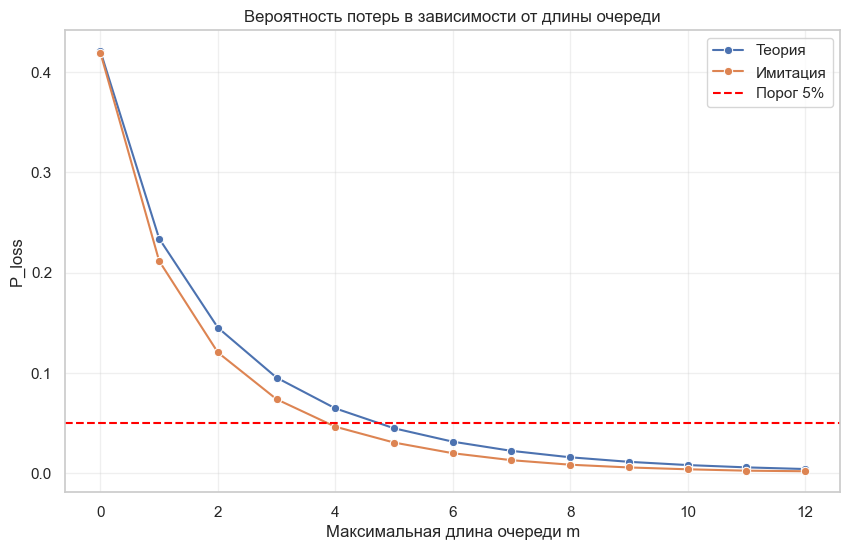

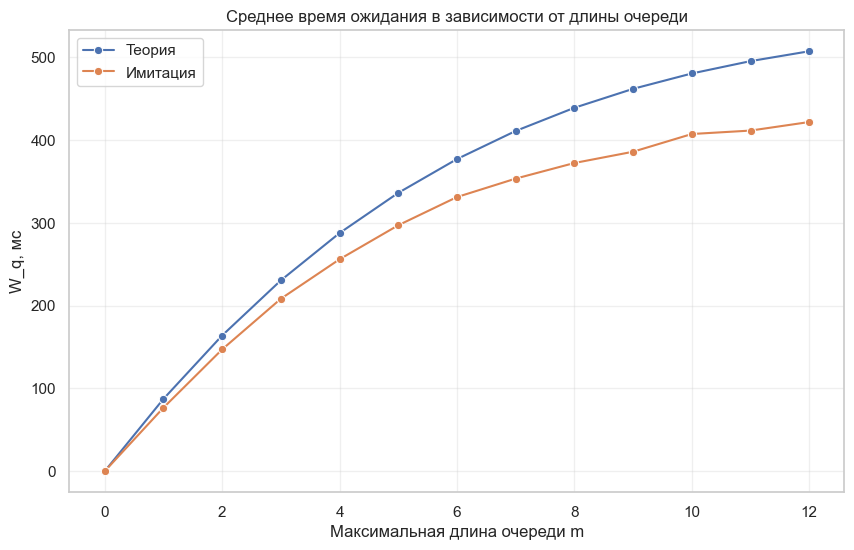

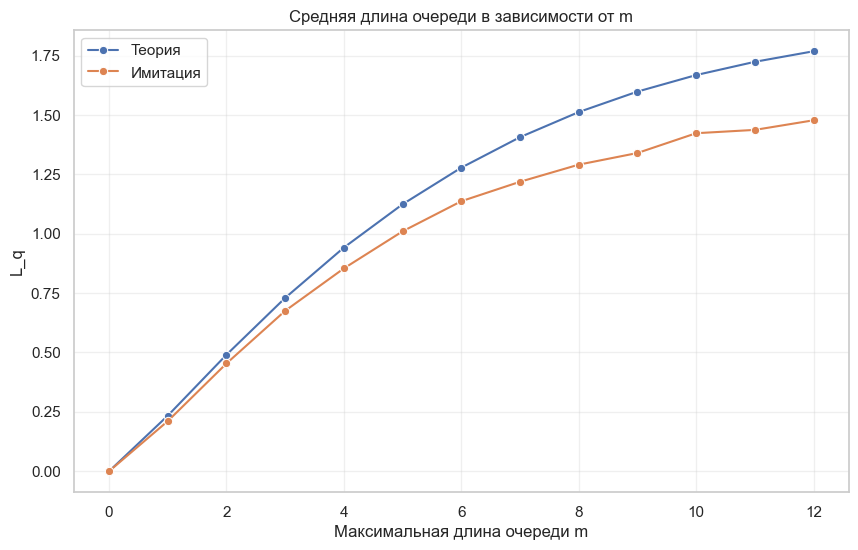

In [40]:
plt.figure()
sns.lineplot(data=optimization_results, x="m", y="P_loss (теор.)", marker="o", label="Теория")
sns.lineplot(data=optimization_results, x="m", y="P_loss (сим.)", marker="o", label="Имитация")
plt.axhline(loss_threshold, color="red", linestyle="--", label="Порог 5%")
plt.title("Вероятность потерь в зависимости от длины очереди")
plt.xlabel("Максимальная длина очереди m")
plt.ylabel("P_loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure()
sns.lineplot(data=optimization_results, x="m", y="W_q (теор., мс)", marker="o", label="Теория")
sns.lineplot(data=optimization_results, x="m", y="W_q (сим., мс)", marker="o", label="Имитация")
plt.title("Среднее время ожидания в зависимости от длины очереди")
plt.xlabel("Максимальная длина очереди m")
plt.ylabel("W_q, мс")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure()
sns.lineplot(data=optimization_results, x="m", y="L_q (теор.)", marker="o", label="Теория")
sns.lineplot(data=optimization_results, x="m", y="L_q (сим.)", marker="o", label="Имитация")
plt.title("Средняя длина очереди в зависимости от m")
plt.xlabel("Максимальная длина очереди m")
plt.ylabel("L_q")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Область достижимости `P_loss <= 5%`

Ниже показано, какие изменения параметров действительно переводят систему в допустимую область.
Таблица отвечает на два практических вопроса:

- какой `μ_eff` нужен при фиксированном `m` и текущем потоке `λ = 8 qps`;
- какой максимальный `λ` допустим при текущем сервере.


In [41]:
feasibility_results = pd.DataFrame([{'m': 5, 'mu_eff_required_qps': 4.697147, 'mean_service_time_required_ms': 212.895211, 'lambda_max_qps': 3.59147, 'reachable_with_current_system': True}, {'m': 7, 'mu_eff_required_qps': 4.168124, 'mean_service_time_required_ms': 239.91607, 'lambda_max_qps': 4.047303, 'reachable_with_current_system': True}, {'m': 10, 'mu_eff_required_qps': 3.810889, 'mean_service_time_required_ms': 262.405969, 'lambda_max_qps': 4.4267, 'reachable_with_current_system': True}])
feasibility_results


,m,mu_eff_required_qps,mean_service_time_required_ms,lambda_max_qps,reachable_with_current_system
0,5,4.697147,212.895211,3.591470,True
1,7,4.168124,239.916070,4.047303,True
2,10,3.810889,262.405969,4.426700,True


In [42]:
feasibility_results["service_time_gap_ms"] = feasibility_results["mean_service_time_required_ms"] - mean_service_time * 1000.0
feasibility_results


,m,mu_eff_required_qps,mean_service_time_required_ms,lambda_max_qps,reachable_with_current_system,service_time_gap_ms
0,5,4.697147,212.895211,3.591470,True,5.422178
1,7,4.168124,239.916070,4.047303,True,32.443037
2,10,3.810889,262.405969,4.426700,True,54.932936


## Граничный сценарий для проверки

Чтобы показать запас устойчивости, дополнительно рассматривается сценарий на верхней границе допустимого входного потока для `m = 5`.
Это позволяет сравнить теорию и имитацию в точке, где условие `P_loss <= 5%` выполняется почти на пределе.


In [43]:
reachable_lambda_case = {
    "m": 5,
    "lambda_qps": 3.591470325337799,
    "mu_eff_qps": 4.8199035184910315,
    "theory_P_loss": 0.049999999999999975,
    "simulation_P_loss": 0.03402091708599178,
    "theory_W_q_ms": 349.50518166806404,
    "simulation_W_q_ms": 310.9418859501952,
}
pd.Series(reachable_lambda_case)


m                      5.000000
lambda_qps             3.591470
mu_eff_qps             4.819904
theory_P_loss          0.050000
simulation_P_loss      0.034021
theory_W_q_ms        349.505182
simulation_W_q_ms    310.941886
dtype: float64

## Контрольные сценарии


In [44]:
scenario_results = pd.DataFrame([{'Сценарий': 'Малый буфер', 'm': 1, 'P_loss (теор.)': 0.233997, 'P_loss (сим.)': 0.212506, 'W_q (теор., мс)': 87.279331, 'W_q (сим., мс)': 76.532165, 'L_q (теор.)': 0.233997, 'L_q (сим.)': 0.21082}, {'Сценарий': 'Базовый режим', 'm': 5, 'P_loss (теор.)': 0.044934, 'P_loss (сим.)': 0.03021, 'W_q (теор., мс)': 336.289977, 'W_q (сим., мс)': 298.85562, 'L_q (теор.)': 1.124127, 'L_q (сим.)': 1.015723}, {'Сценарий': 'Увеличенный буфер', 'm': 7, 'P_loss (теор.)': 0.02243, 'P_loss (сим.)': 0.013312, 'W_q (теор., мс)': 411.08806, 'W_q (сим., мс)': 353.697346, 'L_q (теор.)': 1.406535, 'L_q (сим.)': 1.221522}, {'Сценарий': 'Большой буфер', 'm': 10, 'P_loss (теор.)': 0.008285, 'P_loss (сим.)': 0.003819, 'W_q (теор., мс)': 480.538535, 'W_q (сим., мс)': 400.671259, 'L_q (теор.)': 1.667951, 'L_q (сим.)': 1.399163}])
scenario_results


,Сценарий,m,P_loss (теор.),P_loss (сим.),"W_q (теор., мс)","W_q (сим., мс)",L_q (теор.),L_q (сим.)
0,Малый буфер,1,0.233997,0.212506,87.279331,76.532165,0.233997,0.210820
1,Базовый режим,5,0.044934,0.030210,336.289977,298.855620,1.124127,1.015723
2,Увеличенный буфер,7,0.022430,0.013312,411.088060,353.697346,1.406535,1.221522
3,Большой буфер,10,0.008285,0.003819,480.538535,400.671259,1.667951,1.399163


## Выводы

1. Ноутбук использует ту же предметную модель обслуживания, что и ЛР2, поэтому ЛР3 опирается не на абстрактное `μ`, а на `μ_eff`, полученное из времени обработки RPC-запроса.
2. Для базового режима теория и имитация дают близкие оценки `P_loss`, `L_q`, `W_q`, `W` и загрузки, что подтверждает корректность модели.
3. При увеличении `m` вероятность потерь уменьшается, но среднее ожидание и средняя длина очереди растут.
4. В выбранной конфигурации `ρ = λ / μ_eff < 1`, поэтому порог `P_loss <= 5%` достижим подбором конечной длины очереди.
5. Для текущего сервера оптимальным в исследованном диапазоне оказывается минимальное значение `m`, при котором потери уже не превышают 5%; граничный допустимый поток при `m = 5` находится около `λ ≈ 3.59 qps`.
